<a href="https://colab.research.google.com/github/anupbatha352-png/northstar-urban-mobility-analysis/blob/main/NorthStar_Python_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# PHASE 4: PYTHON DATA PROCESSING
# Cell 1: Setup and load all datasets
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load all CSVs
customers   = pd.read_csv("customers.csv")
orders      = pd.read_csv("orders.csv")
deliveries  = pd.read_csv("deliveries.csv")
complaints  = pd.read_csv("complaints.csv")
app_events  = pd.read_csv("app_events.csv")
drivers     = pd.read_csv("drivers.csv")
vehicles    = pd.read_csv("vehicles.csv")
hubs        = pd.read_csv("hubs.csv")

print("All 9 datasets loaded successfully.")

All 9 datasets loaded successfully.


In [2]:
# ============================================================
# Cell 2: Missing values + zone standardisation
# ============================================================

# Missing value check
print("=== MISSING VALUES ===")
for name, df in [("customers", customers), ("orders", orders),
                 ("deliveries", deliveries), ("complaints", complaints),
                 ("app_events", app_events), ("drivers", drivers),
                 ("vehicles", vehicles)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name}:")
        for col, count in missing.items():
            print(f"  {col}: {count} ({round(count/len(df)*100,1)}%)")

# Key finding
orphaned = app_events['order_id'].isnull().sum()
print(f"\n=== KEY FINDING ===")
print(f"Orphaned app events (no order_id): {orphaned} out of {len(app_events)} ({round(orphaned/len(app_events)*100,1)}%)")

# Zone standardisation
def clean_zone(zone_str):
    if pd.isna(zone_str) or str(zone_str).strip() == '':
        return 'Unknown'
    zone = str(zone_str).strip().replace('Ctr', 'Central').replace('RiverSide', 'Riverside').title()
    return zone

app_events['zone_clean'] = app_events['zone_context'].apply(clean_zone)
customers['zone_clean'] = customers['home_zone'].apply(clean_zone)

print(f"\nZone spellings before cleaning: {app_events['zone_context'].nunique()}")
print(f"Zone spellings after cleaning:  {app_events['zone_clean'].nunique()}")

=== MISSING VALUES ===

customers:
  loyalty_score: 20 (3.1%)
  preferred_channel: 13 (2.0%)

orders:
  booking_channel: 25 (2.0%)

deliveries:
  delivery_completed_at: 19 (2.0%)
  customer_rating_post_delivery: 14 (1.5%)

complaints:
  compensation_amount: 16 (5.0%)

app_events:
  order_id: 144 (22.5%)

drivers:
  training_score: 7 (4.1%)

vehicles:
  battery_health_pct: 4 (3.3%)

=== KEY FINDING ===
Orphaned app events (no order_id): 144 out of 640 (22.5%)

Zone spellings before cleaning: 16
Zone spellings after cleaning:  7


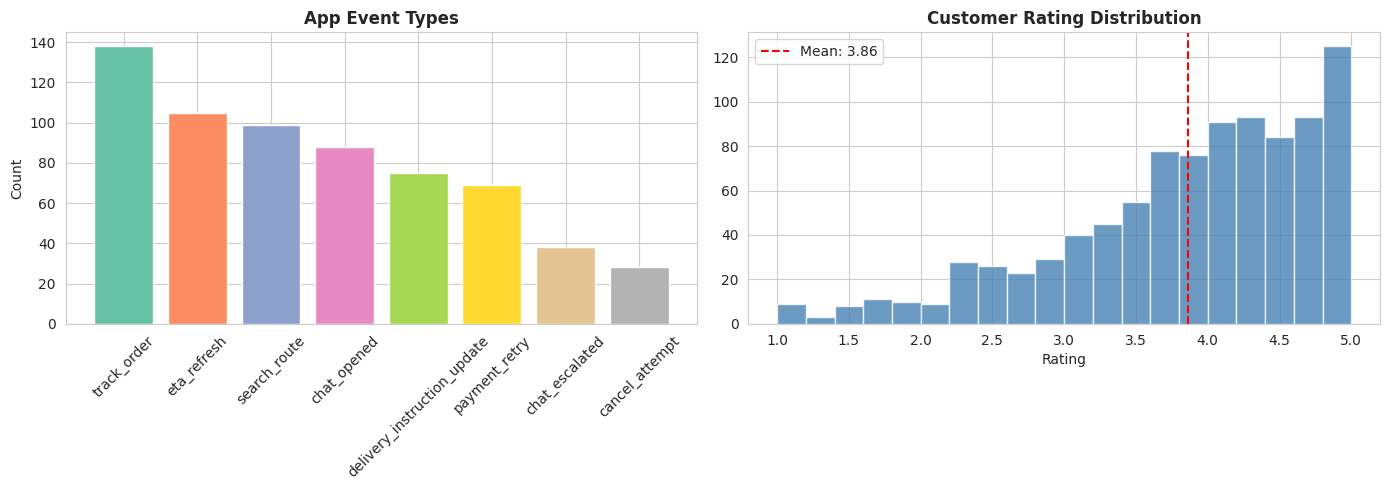

In [3]:
# ============================================================
# Cell 3: Visualisations - app events and customer ratings
# ============================================================

# Chart 1: App event types
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

event_counts = app_events['event_type'].value_counts()
ax1.bar(event_counts.index, event_counts.values, color=sns.color_palette("Set2", len(event_counts)), edgecolor='white')
ax1.set_title("App Event Types", fontweight='bold')
ax1.set_ylabel("Count")
ax1.tick_params(axis='x', rotation=45)

# Chart 2: Customer rating distribution
ratings = deliveries['customer_rating_post_delivery'].dropna()
ax2.hist(ratings, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(ratings.mean(), color='red', linestyle='--', label=f'Mean: {ratings.mean():.2f}')
ax2.set_title("Customer Rating Distribution", fontweight='bold')
ax2.set_xlabel("Rating")
ax2.legend()

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# Cell 4: Create integrated dataset for MongoDB Atlas
# ============================================================

# Merge orders + deliveries + customers
mongo_export = orders[['order_id', 'customer_id', 'service_type', 'pickup_zone',
                        'dropoff_zone', 'order_value']].copy()

mongo_export = mongo_export.merge(
    deliveries[['order_id', 'driver_id', 'delivery_status', 'route_distance_km',
                'manual_route_override_count', 'customer_rating_post_delivery']],
    on='order_id', how='left')

mongo_export = mongo_export.merge(
    customers[['customer_id', 'age', 'zone_clean', 'customer_type', 'loyalty_score']],
    on='customer_id', how='left')

# Add complaint flag
mongo_export['has_complaint'] = mongo_export['order_id'].isin(complaints['order_id']).astype(int)

# Save
mongo_export.to_csv("northstar_integrated_export.csv", index=False)

print(f"✅ Integrated dataset: {mongo_export.shape[0]} rows, {mongo_export.shape[1]} columns")
print(f"✅ Saved: northstar_integrated_export.csv — ready for MongoDB Atlas")
print(f"\nSample:")
print(mongo_export.head(3))

✅ Integrated dataset: 1250 rows, 16 columns
✅ Saved: northstar_integrated_export.csv — ready for MongoDB Atlas

Sample:
  order_id customer_id service_type pickup_zone dropoff_zone  order_value  \
0   O00001       C0292    Passenger     Airport        South       126.65   
1   O00002       C0459    Passenger       North      AIRPORT       109.30   
2   O00003       C0161    Passenger        West      AIRPORT        33.50   

  driver_id delivery_status  route_distance_km  manual_route_override_count  \
0      D047          OnTime              26.65                          2.0   
1       NaN             NaN                NaN                          NaN   
2      D041         Delayed              13.04                          2.0   

   customer_rating_post_delivery  age zone_clean customer_type  loyalty_score  \
0                           4.29   24      South      Consumer           73.2   
1                            NaN   20       West      Consumer           56.1   
2          